# Demo of how to use DEER

To parallelize and therefore accelerate state space models (SSMs).

## Quick start

Welcome! This is a quick demonstration of how to use DEER to parallelize and therefore accelerate state space models (SSMs).

Start by installing this package by running `uv sync` (package is managed with uv).



In [1]:
!pip install git+https://github.com/lindermanlab/micro_deer.git

  Cloning https://github.com/lindermanlab/micro_deer.git to /tmp/pip-req-build-s75052mb
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/micro_deer.git /tmp/pip-req-build-s75052mb
  Resolved https://github.com/lindermanlab/micro_deer.git to commit 4c74ebee39aa4c352edc41a87d665ddc36182662
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.3 MB/s eta 0:00:00
  Created wheel for micro_deer: filename=micro_deer-0.1.0-py3-none-any.whl size=19163 sha256=00633e8ac35a3bdd77bba75bc48107d705ea40e122e2a5d23d531de0feba2a9b
  Stored in directory: /tmp/pip-ephem-wheel-cache-rwn8wlr4/wheels/c9/91/b2/a0ab1bfd619628f307d8714b74484b0c981776f2b26361dd51
Successfully built micro_deer


In [ ]:
%load_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt

from micro_deer.algs.micro_deer import micro_deer_alg
from micro_deer.dynamical_systems.gru import GRU
from micro_deer.dynamical_systems.two_well import (
    TwoWellAnisotropic,
    rand_precision_wishart,
)

Run the below cell to make two experiments: a Langevin diffusion and an untrained GRU.

In [4]:
D = 8
k1, k2, k3, k4, k5 = jr.split(jr.PRNGKey(0), 5)
epsilon = 1e-3
T = 128
langevin_ssm = TwoWellAnisotropic(
    mu1=jnp.ones((D,)),
    mu2=jnp.zeros((D,)),
    prec1=rand_precision_wishart(k4, D),
    prec2=rand_precision_wishart(k5, D),
    epsilon=epsilon,
)
gru_ssm = GRU(D, k3)
inputs = jr.normal(k1, (T, D))
initial_state = jnp.zeros((D,))
states_guess = jr.normal(k2, (T, D))

We now run the GRU sequentially

In [5]:
# the true sequential rollout from the gru
_, gru_sequential = jax.lax.scan(lambda s, u: gru_ssm.scan_fxn(s,u), initial_state, inputs)
gru_sequential = jnp.vstack((initial_state, gru_sequential)) # include initial condition
gru_sequential.shape

(129, 8)

Now we run the GRU in parallel!

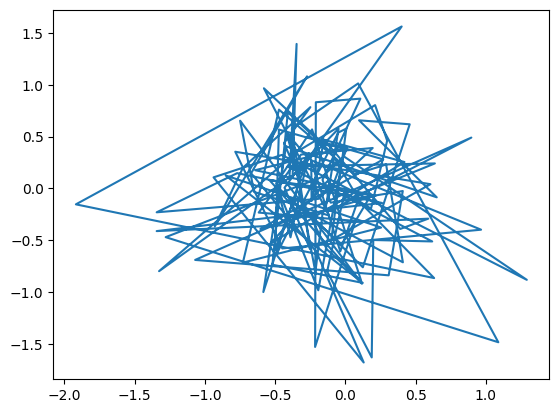

In [6]:
# 2D state space plot of the GRU dynamics (note that dimension is D=8)
plt.plot(gru_sequential[:, 0], gru_sequential[:, 1])

In [7]:
# rollout with DEER and quasi
jacobi_guess = jax.vmap(gru_ssm.deer_fxn, in_axes=(None, 0))(initial_state, inputs) # initialization based on 1 jacobi iter
gru_deer, _, deer_iters = micro_deer_alg(gru_ssm.deer_fxn, initial_state, inputs, jacobi_guess, T)
print(f"shape is {gru_deer.shape}")
print(f"Number of deer iters is {deer_iters}")

gru_quasi, _, quasi_iters = micro_deer_alg(
    gru_ssm.deer_fxn, initial_state, inputs, jacobi_guess, T, quasi=True
)
print(f"shape is {gru_quasi.shape}")
print(f"Number of quasi iters is {quasi_iters}")

shape is (129, 8)
Number of deer iters is 4
shape is (129, 8)
Number of quasi iters is 10


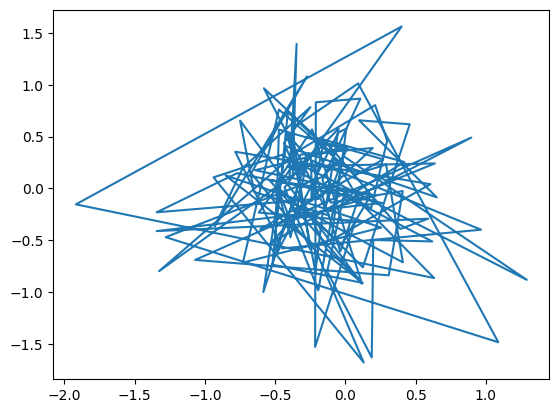

In [8]:
# 2D state space plot of the GRU dynamics (note that dimension is D=8)
plt.plot(gru_deer[:, 0], gru_deer[:, 1])

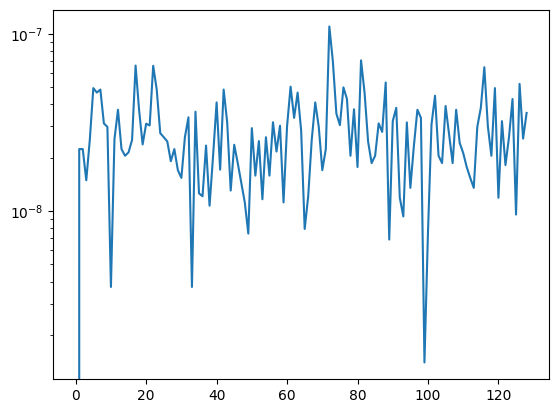

In [ ]:
# error over the time sequence
plt.plot((abs(gru_sequential - gru_deer)).mean(axis=1))
plt.yscale("log")

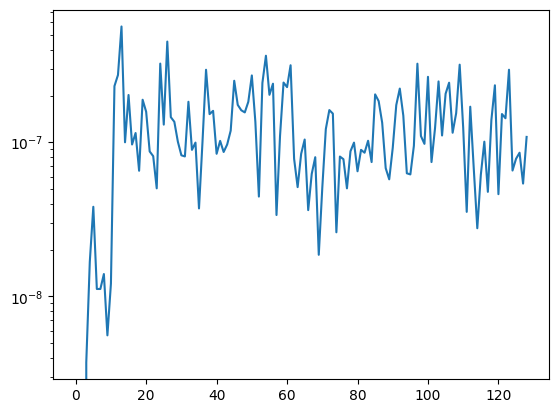

In [ ]:
# error over the time sequence
plt.plot((abs(gru_quasi - gru_deer)).mean(axis=1))
plt.yscale("log")

In [ ]:
!pip install git+https://github.com/lindermanlab/micro_deer.git

In [2]:
!git clone https://github.com/lindermanlab/predictability_enables_parallelization
!cd predictability_enables_parallelization && pip install -e .

Cloning into 'predictability_enables_parallelization'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 55 (delta 10), reused 39 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 6.86 MiB | 7.38 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Obtaining file:///content/predictability_enables_parallelization
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!ls predictability_enables_parallelization/src/
!cat predictability_enables_parallelization/src/deer.py

In [3]:
import sys
sys.path.append('/content/predictability_enables_parallelization/src')

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
from deer import deer_alg, merit_fxn
from lle import wrapper_estimate_lle_from_jacobians

# ── parameters ────────────────────────────────────────────────
dt      = 0.01
sigma_u = 0.5
T       = 1000
NUM_ITERS = 30
N_SEEDS   = 5

# gamma values — vary LLE by changing input coupling
# low gamma → LLE near 0 (weak input, near saddle effect)
# high gamma → more negative LLE (strong input drives away from saddle)
gamma_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

print("Device:", jax.devices())
print(f"T={T} | NUM_ITERS={NUM_ITERS} | N_SEEDS={N_SEEDS}")
print("="*65)
print(f"{'gamma':>8} | {'LLE':>8} | {'rate_beta':>10} | {'converged':>10}")
print("-"*45)

results = []

for gamma in gamma_values:

    def deer_fxn(h, u):
        return h + (h - h**3 + gamma * u) * dt

    # collect rates across seeds
    rates_seeds = []
    lles_seeds  = []

    for seed in range(N_SEEDS):
        key = jr.PRNGKey(seed)
        us  = jr.normal(key, (T, 1)) * sigma_u

        # good initialization — correct basin
        x0    = jnp.array([1.0])
        guess = jnp.ones((T, 1))

        # warmup
        _out = deer_alg(
            deer_fxn, x0, guess, us,
            num_iters=3,
            full_trace=True,
            tol=1e-10
        )
        jax.block_until_ready(_out[1])

        # run with full trace
        _, final, _, _, _, _, _, mf_vals = deer_alg(
            deer_fxn, x0, guess, us,
            num_iters=NUM_ITERS,
            full_trace=True,
            tol=1e-10
        )

        # compute LLE from final trajectory
        # sequential rollout for correct LLE
        h = x0
        traj = [x0]
        for t in range(T):
            h = deer_fxn(h, us[t])
            traj.append(h)
        traj = jnp.array(traj[:-1])  # shape (T, 1)
        Jfs = jax.vmap(jax.jacrev(deer_fxn, argnums=0))(
             traj[:-1], us[1:]
        )
        lle = float(wrapper_estimate_lle_from_jacobians(
            Jfs, jr.PRNGKey(42)
        ))
        lles_seeds.append(lle)

        # ── fit geometric decay on middle iterations only ──────
        # filter: keep only finite positive values
        mf_np = np.array(mf_vals)
        valid_mask = np.isfinite(mf_np) & (mf_np > 1e-32)
        mf_valid   = mf_np[valid_mask]

        if len(mf_valid) < 4:
            continue

        # use middle portion — skip first 2 (transient) and last 2 (plateau)
        n = len(mf_valid)
        mid_start = max(1, int(0.2 * n))
        mid_end   = min(n-1, int(0.8 * n))
        mf_mid    = mf_valid[mid_start:mid_end]

        if len(mf_mid) < 2:
            continue

        # fit log-linear: log(merit) = log(m0) + k*log(beta)
        k_arr  = np.arange(len(mf_mid))
        log_mf = np.log(mf_mid + 1e-32)
        slope, _ = np.polyfit(k_arr, log_mf, 1)
        beta = np.exp(slope)
        rates_seeds.append(float(beta))

    if len(rates_seeds) == 0:
        continue

    med_rate = float(np.median(rates_seeds))
    med_lle  = float(np.median([l for l in lles_seeds
                                if np.isfinite(l)]))

    results.append({
        'gamma'   : gamma,
        'lle'     : lle,
        'beta'    : float(beta),
    })

    print(f"{gamma:>8.3f} | {med_lle:>8.4f} | {med_rate:>10.4f} | "
          f"{'YES' if med_rate < 1.0 else 'NO':>10}")

print("="*65)

# ── arrays ────────────────────────────────────────────────────
lle_arr  = np.array([r['lle']   for r in results])
beta_arr = np.array([r['beta']  for r in results])
gam_arr  = np.array([r['gamma'] for r in results])

# ── plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Panel 1: LLE vs convergence rate
ax = axes[0]
ax.set_facecolor('white')
sc = ax.scatter(lle_arr, beta_arr,
                c=np.log10(gam_arr),
                cmap='viridis', s=120, zorder=5)
plt.colorbar(sc, ax=ax, label='log10(γ)')

# annotate each point
for r in results:
    ax.annotate(f"γ={r['gamma']}",
                xy=(r['lle'], r['beta']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8)

ax.axhline(1.0, color='red', ls='--', lw=1.5,
           label='β=1 (no convergence)')
ax.set_xlabel('LLE λ', fontsize=11)
ax.set_ylabel('Convergence rate β per iteration', fontsize=11)
ax.set_title('LLE vs Convergence Rate\n'
             'Gonzalez: more negative LLE → smaller β → faster convergence',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95,
        f'T={T}\n'
        f'Good init (guess=+1)\n'
        f'Fit on middle iterations\n'
        f'N_seeds={N_SEEDS}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.9))

# Panel 2: gamma vs LLE
ax = axes[1]
ax.set_facecolor('white')
ax.semilogx(gam_arr, lle_arr, 'bo-', ms=8, lw=2,
            label='LLE (measured)')
ax.axhline(0.0, color='red', ls='--', lw=1.5,
           label='LLE=0 (boundary)')
ax.set_xlabel('γ (input coupling)', fontsize=11)
ax.set_ylabel('LLE λ', fontsize=11)
ax.set_title('γ vs LLE\n'
             'Stronger input → more negative LLE',
             fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Convergence Rate vs LLE | Double-well | T={T}\n'
    f'Gonzalez Theorem 4: LLE<0 → geometric convergence | '
    f'More negative LLE → faster convergence',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('lle_vs_convergence_rate.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: lle_vs_convergence_rate.png")

ModuleNotFoundError: No module named 'deer'